In [1]:
import pandas as pd
import talib
import pynance as pn
import matplotlib.pyplot as plt

# Load NVDA stock data from local CSV
df = pd.read_csv('../data/META.csv')

# Convert 'Date' column to datetime objects and set as index for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure numeric data types and handle missing values (clean data)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

print(f"Data loaded: {len(df)} rows.")


Data loaded: 2923 rows.


In [2]:
# --- Moving Averages ---
# SMA helps smooth out price action to identify the long-term trend
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
# EMA gives more weight to recent prices, reacting faster to price changes
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# --- Relative Strength Index (RSI) ---
# Used to identify momentum; values > 70 are 'overbought', < 30 are 'oversold'
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# --- MACD (Moving Average Convergence Divergence) ---
# Measures the relationship between two EMAs to signal trend reversals
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Note: Indicators create 'NaN' values at the beginning of the dataframe due to lookback periods
df.dropna(inplace=True)


In [3]:
# Calculate daily returns (required for PyNance metrics)
daily_returns = df['Close'].pct_change().dropna()

try:
    sharpe = pn.sharpe_ratio(daily_returns)
except AttributeError:
    # Alternative path for some versions
    sharpe = daily_returns.mean() / daily_returns.std() * (252**0.5) 

print(f"META Sharpe Ratio: {sharpe:.4f}")



META Sharpe Ratio: 0.7285


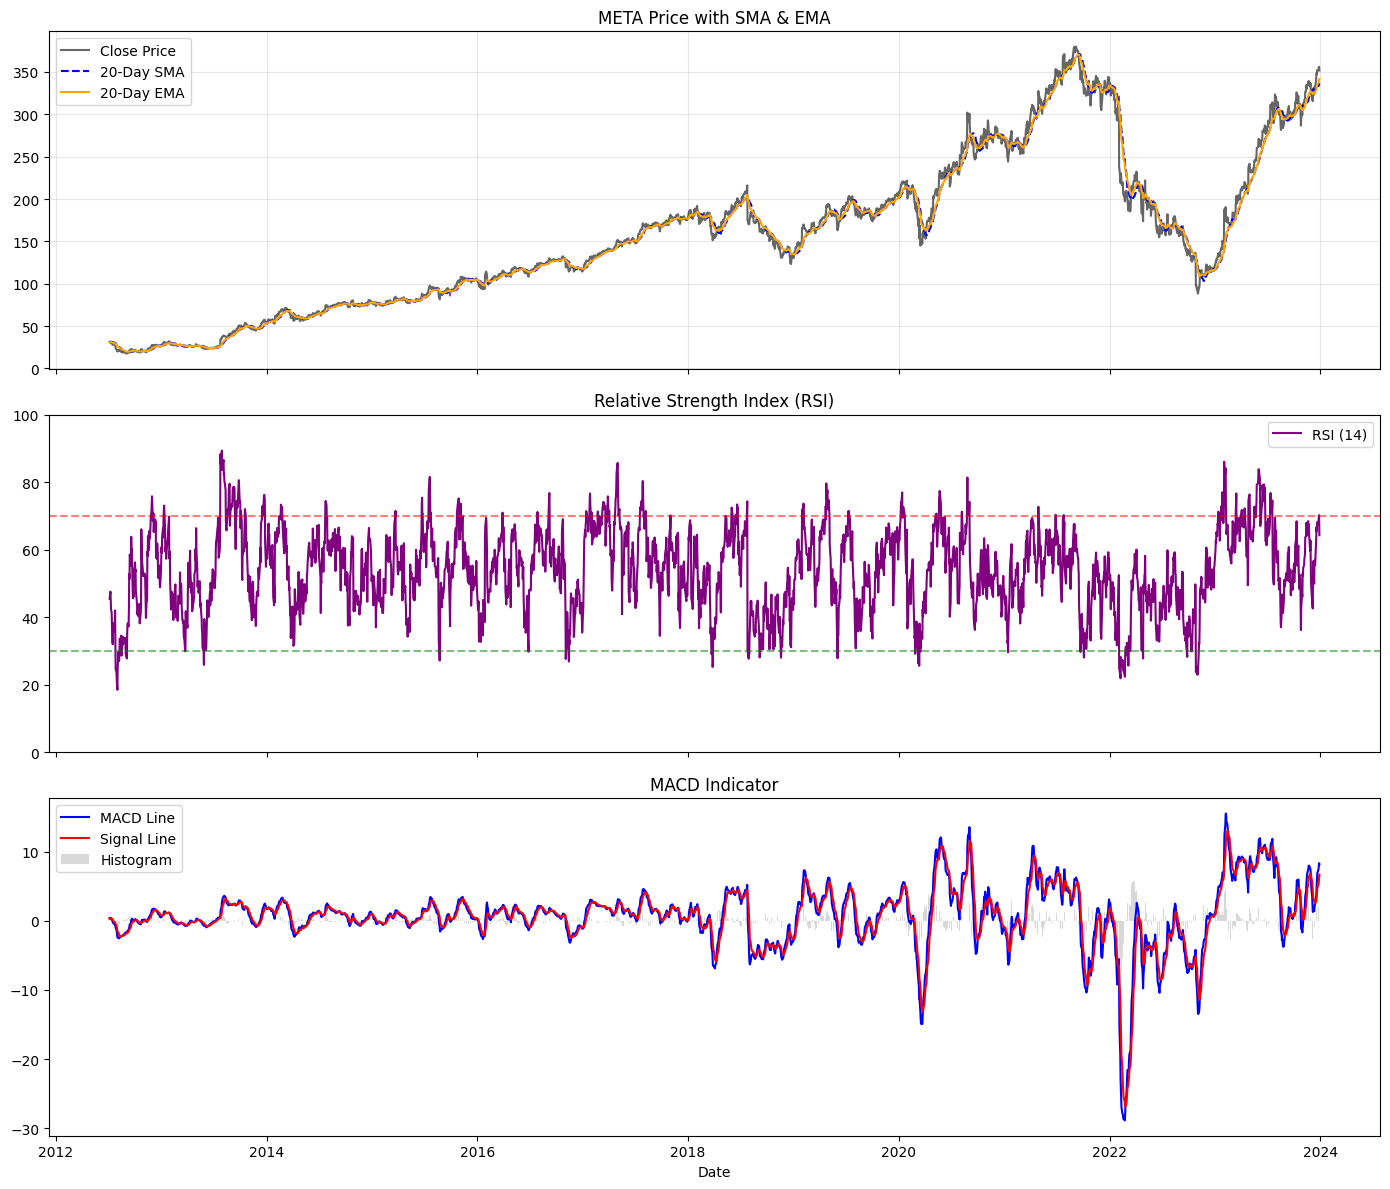

In [5]:
# Create a figure with 3 stacked panels sharing the same X-axis (Dates)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price Action + Moving Averages
ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.6, color='black')
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA', color='blue', linestyle='--')
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA', color='orange')
ax1.set_title('META Price with SMA & EMA')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Panel 2: RSI Momentum
ax2.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)  # Overbought threshold
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold threshold
ax2.set_title('Relative Strength Index (RSI)')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')

# Panel 3: MACD (Trend Momentum)
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='red')
# Histogram shows the distance between MACD and Signal line
ax3.bar(df.index, df['MACD_hist'], label='Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD Indicator')
ax3.legend(loc='best')

# Final formatting
plt.xlabel('Date')
plt.tight_layout()
plt.show()


1. Trend Sensitivity: Price vs. Moving Averages (Panel 1)This panel captures Meta's "high-beta" (volatile) nature:Rapid Reactions: Because Meta often experiences large price gaps following earnings reports or policy shifts, the EMA_20 (Orange) is crucial. If the price pulls away sharply from the orange line, it indicates an unsustainable "stretched" move.The Trend Pivot: When the price crosses both the SMA_20 and EMA_20, it usually marks a major sentiment shift. Meta tends to "trend" for long periods once it picks a direction relative to these averages.2. Momentum Extremes: RSI (Panel 2)The RSI tracks the "fear and greed" index for Meta:The Momentum Ceiling: When Meta’s RSI climbs above the Red Line (70), the stock is frequently in a "frenzy" state. Unlike some slower stocks, Meta can stay overbought for a while during powerful rallies, but a dip back below 70 is often a sharp sell signal.Capitulation Points: Because Meta has experienced deep drawdowns historically, hitting the Green Line (30) often indicates a "capitulation" where sellers are exhausted, marking a high-reward entry point for contrarians.3. Trend Conviction: MACD (Panel 3)The MACD provides the "confirmation" needed to navigate Meta's volatility:Histogram Strength: Look at the size of the Gray Bars. If Meta's price is rising but the histogram bars are getting smaller, it is a "bearish divergence"—warning you that the rally is losing its foundation.Signal Crosses: A Blue Line crossing above the Red Line while both are below the zero-mark is often the first signal of a "dead cat bounce" or a true trend reversal after a major sell-off.4. Risk-Efficiency: The Sharpe RatioThe printed Sharpe Ratio for META is a vital health check:Volatility Penalty: Because Meta has higher volatility than Apple or Google, it needs much higher returns to maintain a good Sharpe Ratio.Interpretation: If the ratio is below 1.0, it suggests that while Meta might be growing, the "ride" is significantly bumpier and riskier compared to the more stable growth seen in other MAG7 stocks.